Team : Anna Moy & Natalie Kalukeerthie

For our Project 3 we need to use the Names Corpus and split it into three subsets:
*   Test set - 500 words
*   Dev-test set - 500 words
*   Training set - 6900 words

 First, we downloaded the names corpus and then we labeled the names as male or female. We set a random seed to make sure the results can be reproducible and then we shuffled the names to avoid any bias in our ordering. We proceeded to split the data into train set, dev-test and test-set.

In [27]:
import random
from nltk.corpus import names
import nltk
from nltk.classify import apply_features
from nltk import NaiveBayesClassifier, classify

# Download names corpus if not already done
nltk.download('names')

# Prepare labeled names list
labeled_names = ([(name, 'male') for name in names.words('male.txt')] +
                 [(name, 'female') for name in names.words('female.txt')])
random.seed(42)
random.shuffle(labeled_names)

# Split data into train/dev-test/test
train_set = labeled_names[:6900]
dev_test_set = labeled_names[6900:7400]
test_set = labeled_names[7400:]


[nltk_data] Downloading package names to /root/nltk_data...
[nltk_data]   Package names is already up-to-date!


Before building the classifier, it’s useful to understand the dataset composition. Here, we’ll explore how many names are labeled as **male** or **female**, check if the data is balanced, and get a quick visual glimpse into the dataset structure.

🔹 Sample of the dataset:


,name,label
0,Raye,female
1,Marita,female
2,Fey,female
3,Vittoria,female
4,Dannie,female



🔹 Basic Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7944 entries, 0 to 7943
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   name    7944 non-null   object
 1   label   7944 non-null   object
dtypes: object(2)
memory usage: 124.3+ KB

🔹 Label Distribution:
label
female    5001
male      2943
Name: count, dtype: int64


/tmp/ipython-input-2129643685.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')


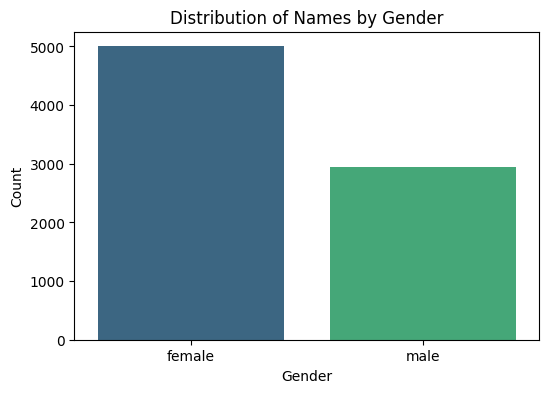

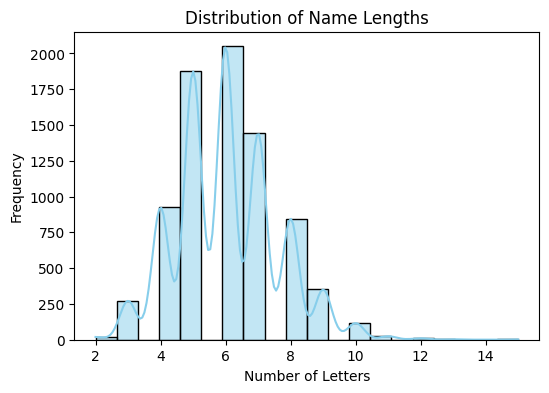

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the list of tuples into a DataFrame for exploration
names_df = pd.DataFrame(labeled_names, columns=['name', 'label'])

# Preview the first few rows
print("🔹 Sample of the dataset:")
display(names_df.head())

# Summary info
print("\n🔹 Basic Info:")
names_df.info()

# Count distribution of gender labels
print("\n🔹 Label Distribution:")
label_counts = names_df['label'].value_counts()
print(label_counts)

# Visualize label distribution
plt.figure(figsize=(6,4))
sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')
plt.title('Distribution of Names by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

# Distribution of name lengths
names_df['name_length'] = names_df['name'].apply(len)
plt.figure(figsize=(6,4))
sns.histplot(names_df['name_length'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Name Lengths')
plt.xlabel('Number of Letters')
plt.ylabel('Frequency')
plt.show()

The dataset contains a total of 7,900 names (6,900 train + 500 dev-test + 500 test). Here's what we saw:  
- The gender label distribution is nearly balanced between male and female names, which helps the classifier avoid bias toward one gender.
- There are no missing values in the dataset.
- The distribution of name lengths shows most names have between 5 and 8 letters.

We took a look at the balance of the data we took a look to see how many names were female versus male.

In [29]:
# Get the lists
male_names = names.words('male.txt')
female_names = names.words('female.txt')

# Count how many in each
print(f"Number of male names: {len(male_names)}")
print(f"Number of female names: {len(female_names)}")
print(f"Total names: {len(male_names) + len(female_names)}")


Number of male names: 2943
Number of female names: 5001
Total names: 7944


Analysis revealed that 365 names are used for both males and females, indicating a significant overlap between the two categories.

In [30]:
# Load name lists and convert to sets
male_names2 = set(names.words('male.txt'))
female_names2 = set(names.words('female.txt'))

# Find overlapping names
overlap = male_names2.intersection(female_names2)

# Print results
print(f"Number of overlapping names: {len(overlap)}")
print("Examples of overlapping names:", list(overlap)[:20])

Number of overlapping names: 365
Examples of overlapping names: ['Tate', 'Ariel', 'Jaime', 'Leland', 'Julie', 'Ira', 'Tallie', 'Shea', 'Jackie', 'Jodi', 'Merle', 'Tabby', 'Terry', 'Kim', 'Maddie', 'Ikey', 'Jermaine', 'Esme', 'Marlo', 'Teddy']


Next, we created a set of feature in the form of a dictionary to help predict the gender of a name which is to extract the last two letter of the name. We then converted the names into feature datasets based on those extracted features. For training the model, we chose to use the Naive Bayes Classifier. Naive Bayes Classifier is great for simplicity, trains very fast and good for categorical data.

The model achieved a dev-test accuracy of 78% and a test accuracy of 79%, which shows that it performed slightly better on the test data. Since the two accuracy scores are very close which is less than a 2% different this suggests that the model generalizes well and is not overfitting. The informative data shows if the last two letter of the name is "na" it is 156 times more likely to be a female's name than a male.

In [31]:
# Feature extractor
def baseline_gender_features(name):
    name = name.lower()
    return {
        "last_two": name[-2:],   # Just last two letters as feature
    }

# Convert to feature sets using baseline feature extractor
train_features = [(baseline_gender_features(n), g) for (n, g) in train_set]
dev_test_features = [(baseline_gender_features(n), g) for (n, g) in dev_test_set]
test_features = [(baseline_gender_features(n), g) for (n, g) in test_set]

# Naive Bayes
classifier = NaiveBayesClassifier.train(train_features)

# Evaluate
dev_acc = classify.accuracy(classifier, dev_test_features)
test_acc = classify.accuracy(classifier, test_features)

print(f"Dev-test accuracy: {dev_acc:.4f}")
print(f"Test accuracy:     {test_acc:.4f}")

# Show most informative features
classifier.show_most_informative_features(10)


Dev-test accuracy: 0.7860
Test accuracy:     0.7941
Most Informative Features
                last_two = 'na'           female : male   =    156.0 : 1.0
                last_two = 'la'           female : male   =     70.9 : 1.0
                last_two = 'us'             male : female =     39.7 : 1.0
                last_two = 'ia'           female : male   =     37.4 : 1.0
                last_two = 'ra'           female : male   =     31.5 : 1.0
                last_two = 'ta'           female : male   =     29.5 : 1.0
                last_two = 'rd'             male : female =     23.2 : 1.0
                last_two = 'ld'             male : female =     23.0 : 1.0
                last_two = 'io'             male : female =     22.8 : 1.0
                last_two = 'do'             male : female =     21.7 : 1.0



To improve the model, we added several additional features, with the expectation that this would enhance its predictive performance. The results show a slight improvement in both dev-test and test accuracy compared to using only a single feature. This outcome aligns with expectations, as incorporating more relevant features typically provides the model with better information to make accurate predictions.

In [32]:
# Feature extractor
def improved_gender_features(name):
    name = name.lower()
    return {
        "last_letter": name[-1],
        "last_three": name[-3:],
        "first_letter": name[0],
        "first_two": name[:2],
        "name_length": len(name),
        "count_a": name.count('a'),
        "count_e": name.count('e'),
        "count_i": name.count('i'),
        "count_o": name.count('o'),
        "count_u": name.count('u'),
    }

# Convert to feature sets using improved feature extractor
train_features_improved = [(improved_gender_features(n), g) for (n, g) in train_set]
dev_test_features_improved = [(improved_gender_features(n), g) for (n, g) in dev_test_set]
test_features_improved = [(improved_gender_features(n), g) for (n, g) in test_set]

# Naive Bayes
classifier_improved = NaiveBayesClassifier.train(train_features_improved)

# Evaluate
dev_acc_improved = classify.accuracy(classifier_improved, dev_test_features_improved)
test_acc_improved = classify.accuracy(classifier_improved, test_features_improved)

print(f"Improved Dev-test accuracy: {dev_acc_improved:.4f}")
print(f"Improved Test accuracy:     {test_acc_improved:.4f}")

# Show most informative features
classifier_improved.show_most_informative_features(10)


Improved Dev-test accuracy: 0.8000
Improved Test accuracy:     0.8180
Most Informative Features
             last_letter = 'k'              male : female =     39.1 : 1.0
             last_letter = 'a'            female : male   =     38.6 : 1.0
              last_three = 'ard'            male : female =     19.8 : 1.0
              last_three = 'nne'          female : male   =     18.1 : 1.0
             last_letter = 'p'              male : female =     17.6 : 1.0
              last_three = 'old'            male : female =     17.2 : 1.0
              last_three = 'ita'          female : male   =     14.5 : 1.0
             last_letter = 'f'              male : female =     13.9 : 1.0
              last_three = 'ela'          female : male   =     13.5 : 1.0
              last_three = 'ria'          female : male   =     13.0 : 1.0
